In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import files
df = files.upload()


Saving Data1.csv to Data1.csv


In [3]:
#Read exel file
df = pd.read_csv('Data1.csv')
# Display first  rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Summary Statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.7500

In [5]:
df.shape

(200, 5)

In [6]:
df.isnull().any()

,0
CustomerID,False
Gender,False
Age,False
Annual Income (k$),False
Spending Score (1-100),False


In [7]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


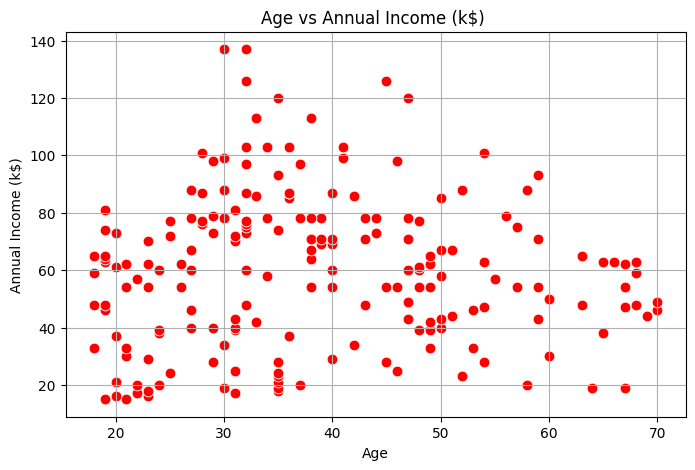

In [8]:
# Visualization to verify
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Annual Income (k$)', data=df, color='red', s=60)
plt.title("Age vs Annual Income (k$) ")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.grid(True)
plt.show()

**Objective**

The objective of this study is to identify and model non-linear relationships between customer characteristics and spending score using Polynomial Regression. Unlike Linear Regression, Polynomial Regression captures curved and complex relationships between independent and dependent variables.

In [15]:
# Independent and dependent variables
X = df[['Annual Income (k$)']].values
y = df['Spending Score (1-100)'].values

In [16]:
# Step 3: Linear Regression (Baseline)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_linear = lin_reg.predict(X)
r2_linear = r2_score(y, y_pred_linear)

# Step 4: Polynomial Regression (Degree 2 and 3)

# Degree 2 (Quadratic)
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X)

poly_reg2 = LinearRegression()
poly_reg2.fit(X_poly2, y)
y_pred_poly2 = poly_reg2.predict(X_poly2)
r2_poly2 = r2_score(y, y_pred_poly2)

In [17]:
# Degree 3 (Cubic) - optional comparison
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X)

poly_reg3 = LinearRegression()
poly_reg3.fit(X_poly3, y)
y_pred_poly3 = poly_reg3.predict(X_poly3)
r2_poly3 = r2_score(y, y_pred_poly3)

In [18]:
# Step 5: Evaluate Models
print("\nModel Performance Comparison:")
print(f"Linear Regression R² Score: {r2_linear:.4f}")
print(f"Polynomial (Degree 2) R² Score: {r2_poly2:.4f}")
print(f"Polynomial (Degree 3) R² Score: {r2_poly3:.4f}")


Model Performance Comparison:
Linear Regression R² Score: 0.0001
Polynomial (Degree 2) R² Score: 0.0001
Polynomial (Degree 3) R² Score: 0.0002


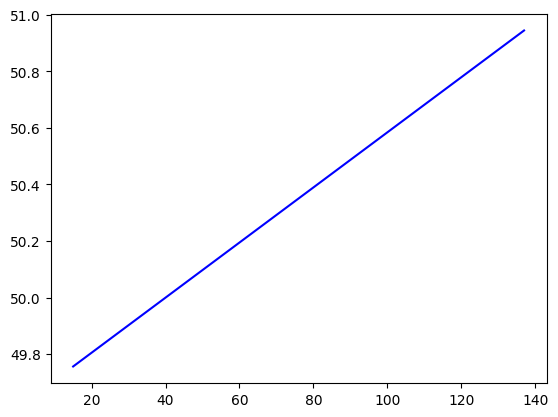

In [19]:
# Linear Regression line
plt.plot(X, y_pred_linear, color='blue', label=f'Linear Fit (R²={r2_linear:.3f})')

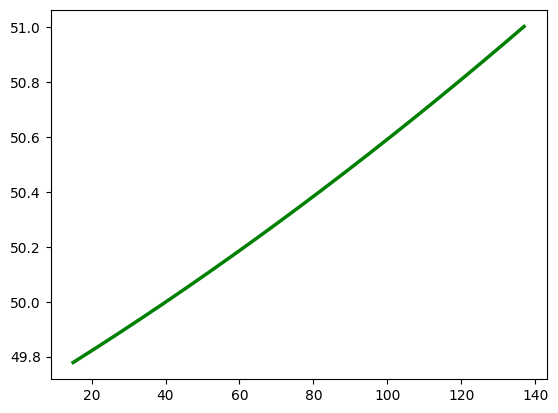

In [20]:
# Polynomial (Degree 2) curve
X_grid = np.linspace(min(X), max(X), 200).reshape(-1,1)
plt.plot(X_grid, poly_reg2.predict(poly2.transform(X_grid)), color='green', linewidth=2.5,
         label=f'Polynomial (Degree 2) Fit (R²={r2_poly2:.3f})')

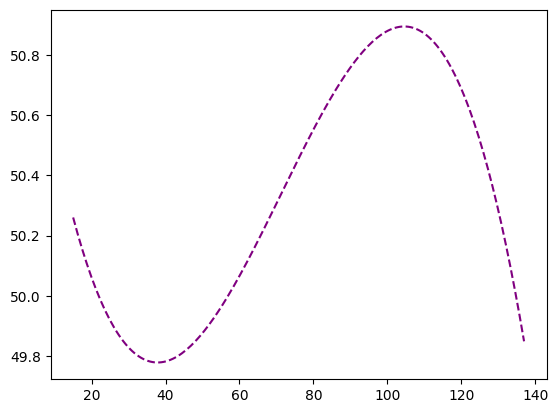

In [ ]:
# Polynomial (Degree 3) curve
plt.plot(X_grid, poly_reg3.predict(poly3.transform(X_grid)), color='purple', linestyle='--',
         label=f'Polynomial (Degree 3) Fit (R²={r2_poly3:.3f})')

In [21]:
# Step 7: Model Evaluation Metrics
from sklearn.metrics import mean_squared_error

mse_poly2 = mean_squared_error(y, y_pred_poly2)
mse_poly3 = mean_squared_error(y, y_pred_poly3)

print("\nPolynomial Regression Model Details:")
print(f"Degree 2 Coefficients: {poly_reg2.coef_}")
print(f"Degree 2 Intercept: {poly_reg2.intercept_}")
print(f"Degree 2 MSE: {mse_poly2:.4f}")

print(f"\nDegree 3 Coefficients: {poly_reg3.coef_}")
print(f"Degree 3 Intercept: {poly_reg3.intercept_}")
print(f"Degree 3 MSE: {mse_poly3:.4f}")


Polynomial Regression Model Details:
Degree 2 Coefficients: [0.00000000e+00 8.09199430e-03 1.26999929e-05]
Degree 2 Intercept: 49.654654325773585
Degree 2 MSE: 663.4548

Degree 3 Coefficients: [ 0.00000000e+00 -8.92625341e-02  1.60618564e-03 -7.51834826e-06]
Degree 3 Intercept: 51.26317144265015
Degree 3 MSE: 663.4037


Conclusion

The dataset contains 	Gender, Age, Annual Income (k$), CustomerID	,	Spending Score (1-100).The objective was to predict spending score using Polynomial Regression

The Linear Regression model achieved an R² score of 0.0001, showing  prediction accuracy and indicating that a straight-line relationship does not fit the data well. In comparison, Polynomial Regression Degree 2 significantly improved the model with an R² score of  0.0001 and MSE of 663.4548. Further improvement was observed with Polynomial Regression Degree 3, which achieved the highest R² score of   0.0002 and the lowest MSE of  663.4037.

The Degree 2 and Degree 3 polynomial coefficients and intercept values helped capture the non-linear relationship between Annual income and spendin score. Since the Degree 3 model provides the highest accuracy and lowest prediction error, it is considered the best model for this dataset. This shows that employee spending score and Annual income have a strong non-linear relationship, which polynomial regression models can capture more effectively than linear regression.